In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import random

/Users/mbouchou/envs/ml-env/lib/python3.11/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


### --- 1. CONFIGURATION ---

In [66]:
TEST_DIR = '/Users/mbouchou/Downloads/airbus-ship-detection/test_v2/'
MODEL_PATH = 'finetuned_model_512.tflite'
THRESHOLD = 0.90  # Adjust visualization threshold if needed

### --- 2. ENVIRONMENT SETUP ---

In [59]:
# Fix for segmentation_models compatibility
os.environ["SM_FRAMEWORK"] = "tf.keras"
import tensorflow.keras as keras
import tensorflow.keras.utils
if not hasattr(keras.utils, 'generic_utils'):
    print("Patching keras.utils.generic_utils")
    keras.utils.generic_utils = keras.utils

from segmentation_models import get_preprocessing

### --- 3. LOAD MODEL ---

In [60]:
print(f"Loading model from: {MODEL_PATH}")
interpreter = tf.lite.Interpreter(model_path=MODEL_PATH)
interpreter.allocate_tensors()
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()
h_model, w_model = input_details[0]['shape'][1], input_details[0]['shape'][2]

# Prepare preprocessing function (ResNet34 expects RGB)
preprocess_input = get_preprocessing('resnet34')

Loading model from: final_model.tflite


### --- 4. LOAD & PREPROCESS IMAGE ---

Processing image: c8fbde1c9.jpg


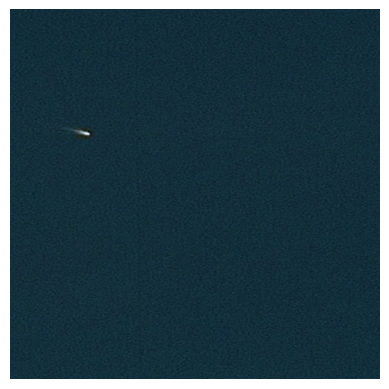

In [77]:
# Pick a random image from the directory
all_files = os.listdir(TEST_DIR)
img_name = random.choice(all_files)
img_path = os.path.join(TEST_DIR, img_name)

print(f"Processing image: {img_name}")
from PIL import Image
# Load and show image
img = Image.open(img_path)
plt.imshow(img)
plt.axis("off")
plt.show()

In [ ]:
# Load Image (OpenCV loads as BGR)
img = cv2.imread(img_path)
if img is None:
    raise FileNotFoundError(f"Could not load image at {img_path}")

# Resize to model input size (e.g., 512x512)
img_resized = cv2.resize(img, (w_model, h_model))

# CRITICAL: Convert BGR to RGB
img_rgb = cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB)

# Normalize/Preprocess
img_float = img_rgb.astype(np.float32)
img_input = preprocess_input(img_float)
img_input = np.expand_dims(img_input, axis=0)

### --- 5. INFERENCE ---

In [80]:
interpreter.set_tensor(input_details[0]['index'], img_input)
interpreter.invoke()
pred_raw = interpreter.get_tensor(output_details[0]['index'])[0, :, :, 0]

### --- 6. DISPLAY RESULTS ---

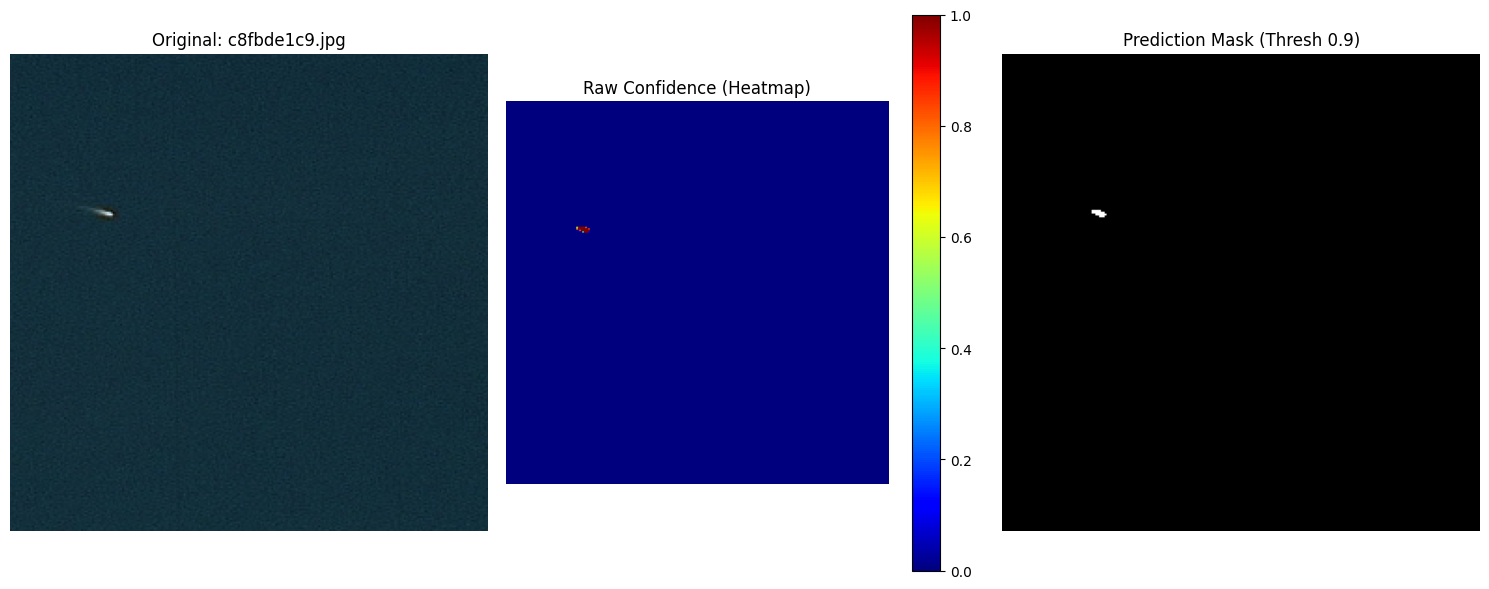

In [81]:
# Apply threshold for the mask view
pred_mask = (pred_raw > THRESHOLD).astype(np.float32)

plt.figure(figsize=(15, 6))

# Subplot 1: Original Image
plt.subplot(1, 3, 1)
plt.imshow(img_rgb)
plt.title(f"Original: {img_name}")
plt.axis('off')

# Subplot 2: Raw Confidence Map (Heatmap)
plt.subplot(1, 3, 2)
plt.imshow(pred_raw, cmap='jet', vmin=0, vmax=1)
plt.title("Raw Confidence (Heatmap)")
plt.colorbar()
plt.axis('off')

# Subplot 3: Final Binary Mask
plt.subplot(1, 3, 3)
plt.imshow(pred_mask, cmap='gray')
plt.title(f"Prediction Mask (Thresh {THRESHOLD})")
plt.axis('off')

plt.tight_layout()
plt.show()